# Is there a signal at all? — the four-step evaluation study

The two selection notebooks ([feature_selection.ipynb](feature_selection.ipynb),
[windowed_selection.ipynb](windowed_selection.ipynb)) both produce a positive
out-of-sample IC. **So does the same pipeline run on shuffled labels.** This
notebook is the study that tells the two apart.

Four steps, each changing one thing and re-measured against the same bar:

| step | change | question it answers |
|---|---|---|
| **3** | a shuffled-label **null**, built into the package | what does this pipeline score when there is nothing to find? |
| **1** | a purged **holdout** the selection never sees | does anything survive on data used exactly once? |
| **2** | window **normalisation** | is the result the price LEVEL acting as a proxy for the date? |
| **4** | a market-**relative** target | is the absolute return just the market factor, which no company feature predicts? |

⚠️ Step 3 is done first on purpose. Steps 1, 2 and 4 all produce a number, and a
number without a bar is not a result.

## The bar is not zero

A selection always earns a positive IC — picking the best 12 of 27 channels by
their fit to the labels earns one from noise alone. `evaluation.null_distribution`
re-runs the **whole pipeline, selection included** on block-shuffled labels
(blocks of `d + h`, so the label's own autocorrelation survives and the null is not
made artificially tight). The p95 of that distribution is the bar.

⚠️ **Re-run the null whenever the candidate pool or the representation changes.** A
wider pool, or a standardised one, has more room to overfit — the bar moves with it,
and this notebook shows it moving.

## Imports & parameters

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from feature_selection import evaluation, plots
from feature_selection.selector import FeatureSelector
from feature_selection.unified_reader import UnifiedSchemaReader

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
plots.use_theme()

In [2]:
TICKER = "VCB"
LOOKBACK = 20            # d
HORIZON = 5              # h
HOLDOUT_START = "2024-06-01"
N_NULL = 10              # draws per configuration; p-value resolution ~1/(N+1)

MAX_FEATURES = 12
CORR_THRESHOLD = 0.9
N_SPLITS = 5
MIN_TRAIN = 500

ALL_TARGETS = ["return_5day", "return_10day", "return_rel_5day", "return_rel_10day"]
BASE_EXCLUDE = [
    "exchange", "ticker", "sector", "sector_code", "industry_group",
    "industry_group_code", "industry", "industry_code",
    "sub_industry", "sub_industry_code",
]

# The grid: three representations against the absolute target, two against the
# market-relative one.
CONFIGS = [
    ("return_5day", "none"),
    ("return_5day", "zscore"),
    ("return_5day", "window_relative"),
    ("return_rel_5day", "none"),
    ("return_rel_5day", "zscore"),
]

## The data

`pool__targets` now carries four labels — two horizons × {absolute, market-relative}.
The relative one subtracts the VNINDEX return over the same window
(`gold_schema.stock_market.hose__vnindex__close_adjust`).

⚠️ `return_rel_*` has **more nulls than its own tail**: one session (2024-05-17) has
no VNINDEX close, and a benchmark gap at `t` kills row `t` and at `t+h` kills row
`t−h`. The asset asserts the count stays within that bound rather than absorbing it.

In [3]:
reader = UnifiedSchemaReader(TICKER).connect()
panel = reader.join(["pool__basic", "pool__targets"])
reader.close()

labels = pd.DataFrame({
    "target": ALL_TARGETS,
    "labelled": [int(panel[c].notna().sum()) for c in ALL_TARGETS],
    "null": [int(panel[c].isna().sum()) for c in ALL_TARGETS],
    "mean": [round(float(panel[c].mean()), 5) for c in ALL_TARGETS],
    "sd": [round(float(panel[c].std()), 5) for c in ALL_TARGETS],
    "min": [round(float(panel[c].min()), 4) for c in ALL_TARGETS],
    "max": [round(float(panel[c].max()), 4) for c in ALL_TARGETS],
})
labels

,target,labelled,null,mean,sd,min,max
0,return_5day,4230,5,0.00319,0.04295,-0.1876,0.2914
1,return_10day,4225,10,0.00646,0.05983,-0.2742,0.3310
2,return_rel_5day,4228,7,0.00105,0.03205,-0.1216,0.2575
3,return_rel_10day,4223,12,0.00217,0.04383,-0.1833,0.2514


⚠️ Read the `sd` column: the relative target's dispersion is **smaller** than the
absolute one's. That is the market factor being removed — and it is the entire
premise of step 4, visible before any model is fitted.

## Run the grid

Each configuration gets: a development walk-forward, a holdout scored once with a
shuffled control, and its own null.

In [4]:
def selector_for(target, normalize, frame):
    return FeatureSelector(
        panel=frame, target=target,
        exclude=BASE_EXCLUDE + [t for t in ALL_TARGETS if t != target],
        max_features=MAX_FEATURES, corr_threshold=CORR_THRESHOLD,
        horizon=HORIZON, lookback=LOOKBACK, n_splits=N_SPLITS,
        min_train=MIN_TRAIN, device="cpu",
        normalize=normalize, holdout_start=HOLDOUT_START,
    )


results, devs, nulls, holds = {}, [], [], []
for target, normalize in CONFIGS:
    tag = f"{target} / {normalize}"
    selector = selector_for(target, normalize, panel)
    result = selector.run(stability=False)
    dev = evaluation.ic_summary(result.validation, HORIZON).rename(tag)
    null = evaluation.null_distribution(
        panel=panel, target=target,
        factory=lambda f, t=target, n=normalize: selector_for(t, n, f).run(
            stability=False
        ),
        observed=dev["ic_mean"], horizon=HORIZON, lookback=LOOKBACK,
        n_draws=N_NULL, seed=1, label=tag, progress=False,
    )
    results[tag] = (result, null)
    devs.append(dev)
    nulls.append(null.summary())
    holds.append(selector.score_holdout(result).assign(config=tag))
    print(f"{tag:<34} dev IC {dev['ic_mean']:+.4f}  bar {null.bar:+.4f}  "
          f"{'CLEARS' if null.clears else 'inside the null'}")

return_5day / none                 dev IC +0.0462  bar +0.0554  inside the null


return_5day / zscore               dev IC +0.0381  bar +0.0542  inside the null


return_5day / window_relative      dev IC +0.0002  bar +0.0436  inside the null


return_rel_5day / none             dev IC +0.0134  bar +0.0609  inside the null


return_rel_5day / zscore           dev IC -0.0311  bar +0.0445  inside the null


## Step 3 — the bar, per configuration

⚠️ **`null_mean` is not zero, and it moves.** That is the selection bias, and it is
larger for the standardised representation because standardised windows give the
selector more room to overfit. A single bar reused across configurations would have
compared them unfairly.

In [5]:
null_table = pd.DataFrame(nulls).T
null_table

,return_5day / none,return_5day / zscore,return_5day / window_relative,return_rel_5day / none,return_rel_5day / zscore
label,return_5day / none,return_5day / zscore,return_5day / window_relative,return_rel_5day / none,return_rel_5day / zscore
observed_ic,0.0462,0.0381,0.0002,0.0134,-0.0311
null_mean,0.012,0.0213,0.0066,0.0015,-0.0009
null_sd,0.0314,0.0214,0.0273,0.0404,0.0266
null_p95_BAR,0.0554,0.0542,0.0436,0.0609,0.0445
null_max,0.0575,0.0606,0.058,0.0899,0.0558
p_value,0.1818,0.1818,0.5455,0.1818,0.8182
z_vs_null,1.09,0.79,-0.23,0.29,-1.14
clears_bar,False,False,False,False,False
draws,10,10,10,10,10


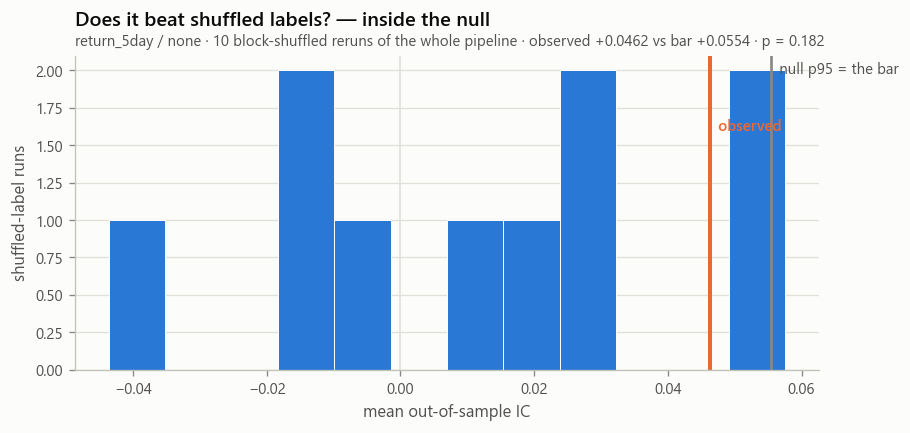

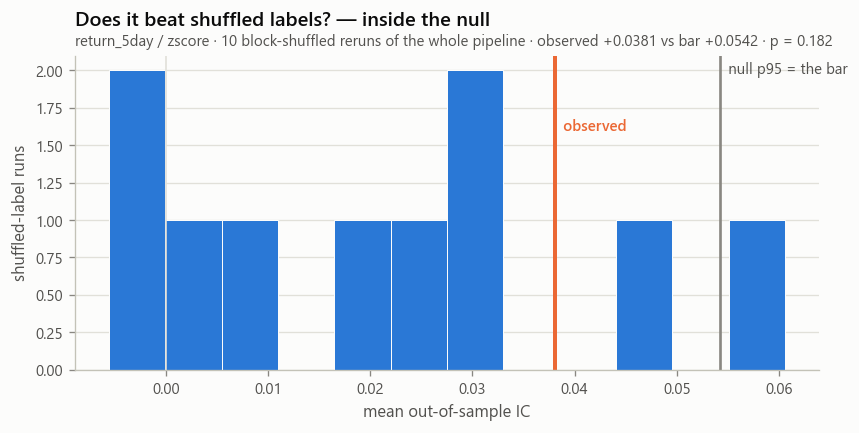

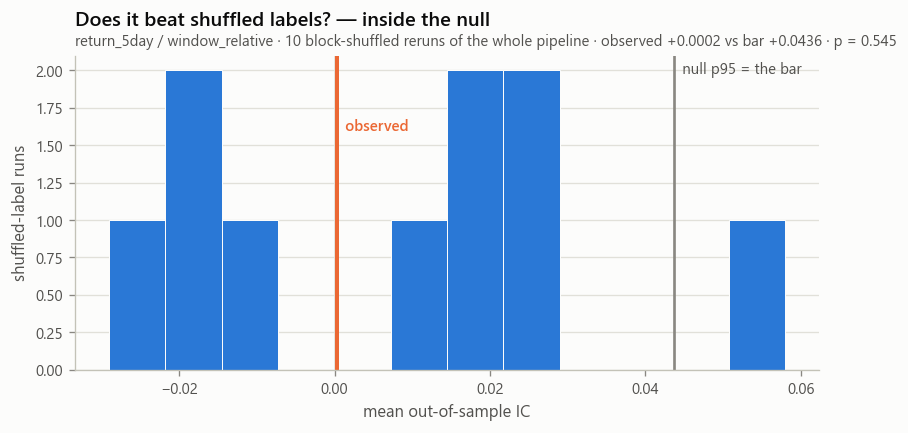

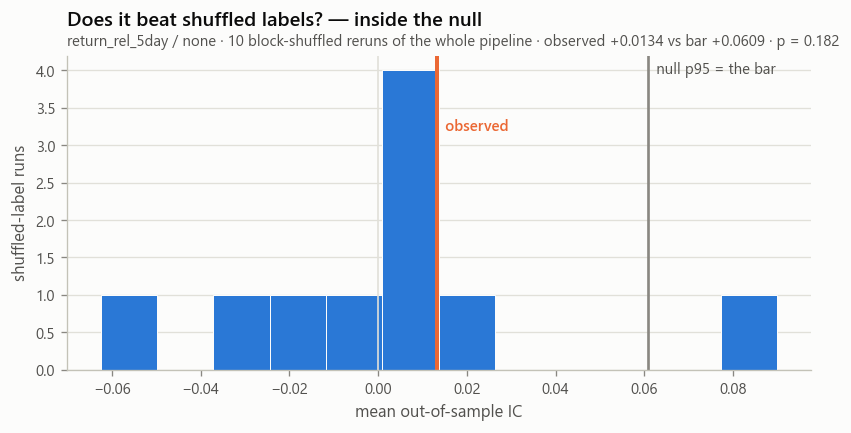

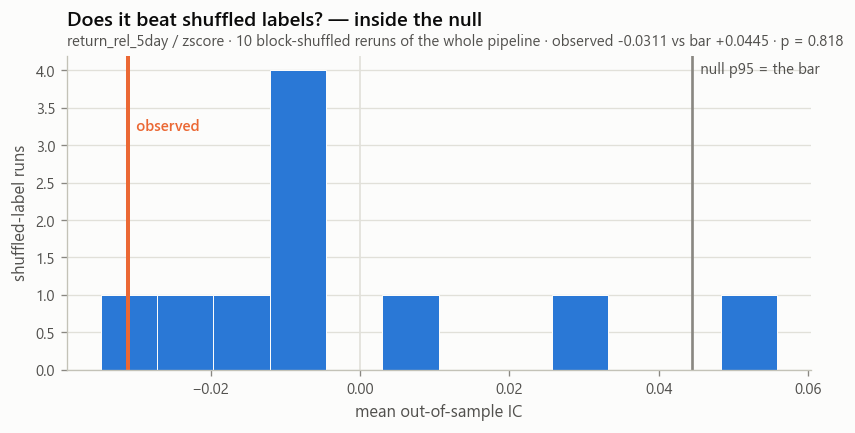

In [6]:
for tag, (_, null) in results.items():
    plots.plot_null(null)
    plt.show()

## Steps 1, 2 and 4 — the development walk-forward

`ic_trend_per_fold` matters as much as `ic_mean`: a mean built from folds that decay
to negative is not a signal that averages that mean.

`n_eff_per_fold` is `n_test / h` — the independent observations behind each fold's
IC — and `se_ic_per_fold` is the error bar it implies. Compare it to `ic_fold_sd`.

In [7]:
dev_table = pd.DataFrame(devs).T.round(4)
dev_table

,return_5day / none,return_5day / zscore,return_5day / window_relative,return_rel_5day / none,return_rel_5day / zscore
folds,5.0000,5.0000,5.0000,5.0000,5.0000
ic_mean,0.0462,0.0381,0.0002,0.0134,-0.0311
ic_trend_per_fold,0.0083,-0.0117,0.0236,-0.0157,0.0130
ic_min,-0.0486,-0.0200,-0.1122,-0.1694,-0.0897
ic_max,0.1312,0.1078,0.0972,0.0890,0.0809
ic_fold_sd,0.0680,0.0554,0.0859,0.1064,0.0661
hit_rate,0.4802,0.5005,0.4846,0.4954,0.4837
n_test_rows,631.0000,631.0000,631.0000,631.0000,631.0000
n_eff_per_fold,126.2000,126.2000,126.2000,126.2000,126.2000
se_ic_per_fold,0.0894,0.0894,0.0894,0.0894,0.0894


## The holdout — and why it cannot decide anything

Scored **once**, on data no ranker, no prune and no fold ever saw. Three rows per
configuration: the selected channels, all channels, and a **shuffled-label control**
trained exactly the same way.

⚠️ **The control is the error bar.** With one score there is no fold spread to read,
so the only way to know whether a holdout IC is large is to see what a model with no
information scores on the same rows.

In [8]:
holdout = pd.concat(holds)[
    ["config", "feature_set", "labels", "n_holdout", "n_eff_holdout", "ic", "hit_rate"]
].round(4)
holdout

,config,feature_set,labels,n_holdout,n_eff_holdout,ic,hit_rate
0,return_5day / none,selected,real,487,97.4,0.0712,0.5359
1,return_5day / none,selected,shuffled control,487,97.4,-0.0697,0.4743
2,return_5day / none,all channels,real,487,97.4,0.0610,0.4928
3,return_5day / none,all channels,shuffled control,487,97.4,0.1686,0.5031
0,return_5day / zscore,selected,real,487,97.4,-0.0517,0.4415
1,return_5day / zscore,selected,shuffled control,487,97.4,0.1175,0.5072
2,return_5day / zscore,all channels,real,487,97.4,-0.0037,0.4887
3,return_5day / zscore,all channels,shuffled control,487,97.4,0.0072,0.4702
0,return_5day / window_relative,selected,real,487,97.4,-0.0540,0.4476
1,return_5day / window_relative,selected,shuffled control,487,97.4,-0.1208,0.4230


In [9]:
control = holdout[holdout["labels"] == "shuffled control"]["ic"]
real = holdout[holdout["labels"] == "real"]["ic"]
n_eff = float(holdout["n_eff_holdout"].iloc[0])
print(f"holdout n_eff = {n_eff:.0f}  ->  SE(IC) ~ {1 / np.sqrt(n_eff - 1):.3f}")
print(f"shuffled-label control IC: min {control.min():+.4f}  max {control.max():+.4f}")
print(f"real IC:                   min {real.min():+.4f}  max {real.max():+.4f}")
print("\nIf the control's range covers the real range, the holdout is too small "
      "to separate them.")

holdout n_eff = 97  ->  SE(IC) ~ 0.102
shuffled-label control IC: min -0.1891  max +0.1686
real IC:                   min -0.1069  max +0.0712

If the control's range covers the real range, the holdout is too small to separate them.


## Everything on one axis

In [10]:
comparison = pd.DataFrame({
    "dev_ic": [d["ic_mean"] for d in devs],
    "null_bar_p95": [results[d.name][1].bar for d in devs],
    "clears_bar": [results[d.name][1].clears for d in devs],
    "p_value": [results[d.name][1].p_value for d in devs],
    "ic_trend": [d["ic_trend_per_fold"] for d in devs],
    "hit_rate": [d["hit_rate"] for d in devs],
    "holdout_real": [
        holdout.query("config == @d.name and feature_set == 'selected' "
                      "and labels == 'real'")["ic"].iloc[0] for d in devs
    ],
    "holdout_control": [
        holdout.query("config == @d.name and feature_set == 'selected' "
                      "and labels == 'shuffled control'")["ic"].iloc[0] for d in devs
    ],
}, index=[d.name for d in devs]).round(4)
comparison

,dev_ic,null_bar_p95,clears_bar,p_value,ic_trend,hit_rate,holdout_real,holdout_control
return_5day / none,0.0462,0.0554,False,0.1818,0.0083,0.4802,0.0712,-0.0697
return_5day / zscore,0.0381,0.0542,False,0.1818,-0.0117,0.5005,-0.0517,0.1175
return_5day / window_relative,0.0002,0.0436,False,0.5455,0.0236,0.4846,-0.0540,-0.1208
return_rel_5day / none,0.0134,0.0609,False,0.1818,-0.0157,0.4954,0.0207,-0.0493
return_rel_5day / zscore,-0.0311,0.0445,False,0.8182,0.0130,0.4837,-0.0396,-0.0349


## Reading the study

Fill in from the tables above. The three questions, in order:

1. **Does any configuration clear its own null?** `clears_bar` is the whole result.
   If none does, the ranking, the kept sets and the stat profiles in the other two
   notebooks are descriptions of noise — internally consistent, and about nothing.
2. **What did normalisation do?** If `zscore` and `window_relative` score *lower*
   than `none`, the raw-level result was the price level acting as a proxy for the
   date, and removing it removed the apparent signal. That is a diagnosis, not a
   setback.
3. **Did the relative target help?** It should, if the story is "the market factor
   dominates and no company feature predicts it". If it does not, the limit is not
   the target — it is that one stock's 4,235 sessions carry roughly `4235 / h`
   independent observations, and that is too few to resolve an effect this size.

## What this study cannot do, however long it runs

⚠️ **`n_eff` is the binding constraint, and no feature fixes it.** At `h=5` the whole
17-year history holds ~850 independent observations, and the holdout ~97. An IC of
0.05 needs on the order of 1,500 independent observations to separate from zero at
conventional confidence. **More features cannot buy more observations — they only
raise the null.**

The way out is more *cross-section*, not more features or more history: N stocks × T
days at the same `h` multiplies the independent count by N. That is what
`unified_schema_<ticker>` cannot express by construction — it is one company — and
what memory `project-cross-sectional-strategy` already points at.